# Per-epoch loss — classic (sweep folders) + bound (`loss_curves.json`)

`vanilla` + `p1/p2/p3_classic` losses come from the most_specific sweep folders; `p1/p2/p3_bound`
from the cached `notebooks/synthetic_visuals/cache/loss_curves.json`. Within each TC panel, all
variants are **min-max normalized by that TC's global min/max** (per-panel), so variants keep their
*relative* heights (curves start at different points) while every panel sits on a clean [0,1] axis.
Two versions: **no-norm** classic (`synthetic_benchmark_ms_nonorm`) and **norm=8** classic
(`synthetic_benchmark_ms_norm`); bound is the same (norm-based) in both.

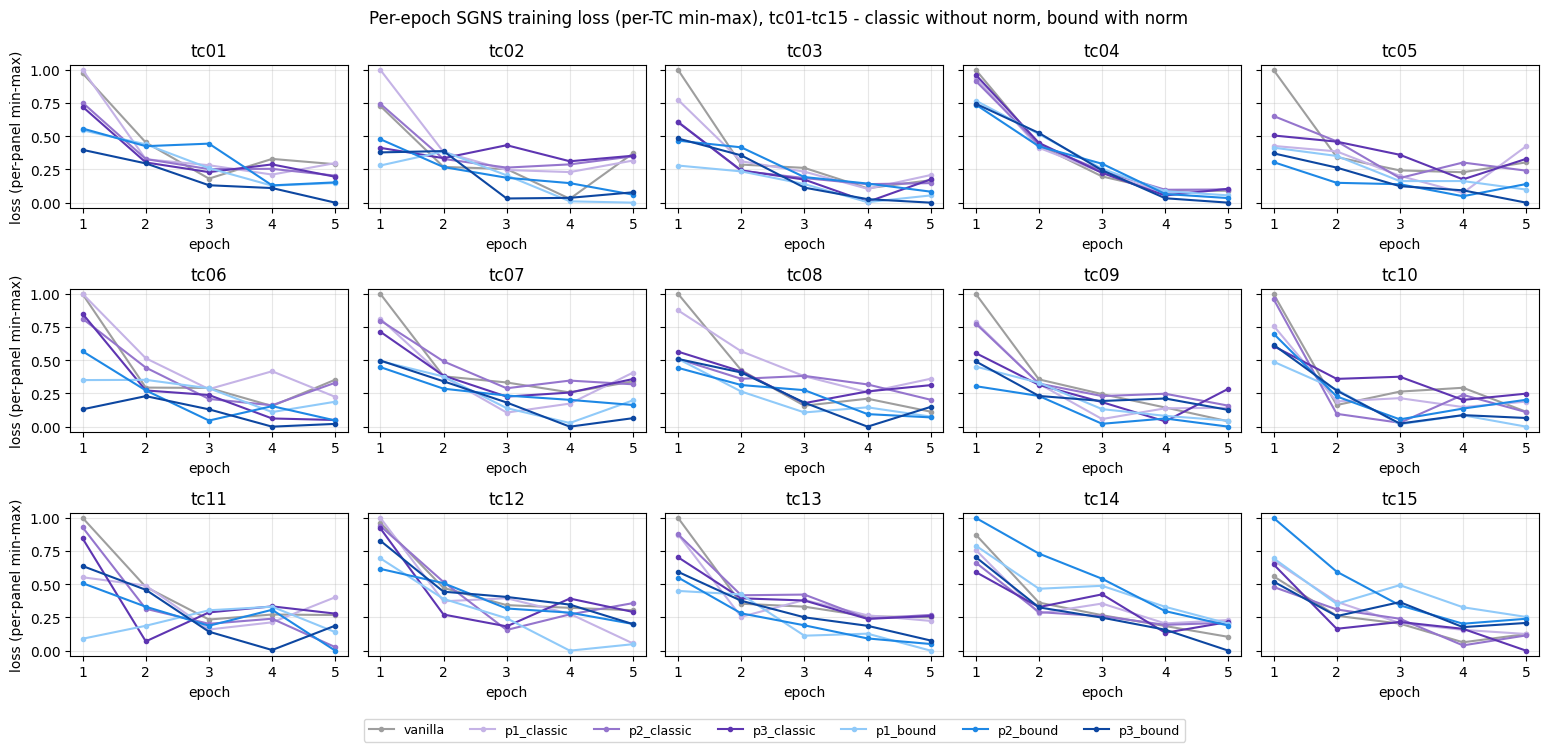

In [1]:
"""Shared setup + plotting function: combined per-epoch loss, per-TC (per-panel) min-max."""
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "output").exists() and ROOT != ROOT.parent:   # find repo root from notebook cwd
    ROOT = ROOT.parent

EPOCHS = 5
BOUND_JSON = ROOT / "notebooks" / "synthetic_visuals" / "cache" / "loss_curves.json"
CURVE_TCS = [f"tc{i:02d}" for i in range(1, 16)]
CLASSIC_VARS = ["vanilla", "p1_classic", "p2_classic", "p3_classic"]
BOUND_VARS = ["p1_bound", "p2_bound", "p3_bound"]
PLOT_VARIANTS = CLASSIC_VARS + BOUND_VARS
ALL_COLORS = {
    "vanilla": "#9e9e9e",
    "p1_classic": "#c5b3e6", "p2_classic": "#9575cd", "p3_classic": "#5e35b1",
    "p1_bound": "#90caf9", "p2_bound": "#1e88e5", "p3_bound": "#0d47a1",
}
_bound_json = json.loads(BOUND_JSON.read_text())


def plot_combined_loss(classic_subdir):
    """classic (vanilla, p1/p2/p3) from output/<classic_subdir>; bound from loss_curves.json.

    Per-panel min-max: each TC's curves are normalized by that TC's global min/max across all
    variants, so variants keep their relative heights (curves do NOT all start at 1.0).
    """
    classic_dir = ROOT / "output" / classic_subdir
    src = "no-norm" if "nonorm" in classic_subdir else "norm=8"

    def classic_losses(tc, v):
        f = classic_dir / tc / v / "metrics.json"
        return json.loads(f.read_text())["losses"] if f.is_file() else None

    loss = {}
    for tc in CURVE_TCS:
        loss[tc] = {}
        for v in CLASSIC_VARS:                       # classic + vanilla from the sweep folders
            ls = classic_losses(tc, v)
            if ls:
                loss[tc][v] = ls
        for v in BOUND_VARS:                          # bound from the cached loss_curves.json
            ls = _bound_json.get(tc, {}).get(v)
            if ls:
                loss[tc][v] = ls

    ncol = 5
    nrow = int(np.ceil(len(CURVE_TCS) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.5 * nrow), sharey=True)
    axes = np.atleast_2d(axes)
    for ax, tc in zip(axes.flat, CURVE_TCS):
        vals = [x for v in PLOT_VARIANTS if loss[tc].get(v) for x in loss[tc][v]]   # all variants, this TC
        gmin, gmax = (min(vals), max(vals)) if vals else (0.0, 1.0)
        for v in PLOT_VARIANTS:
            losses = loss[tc].get(v)
            if not losses:
                continue
            arr = np.asarray(losses, dtype=float)
            rel = (arr - gmin) / (gmax - gmin) if gmax > gmin else np.zeros_like(arr)   # per-panel min-max
            ep = np.arange(1, len(rel) + 1)
            ax.plot(ep, rel, marker="o", ms=3, color=ALL_COLORS[v], label=v)
        ax.set_title(tc); ax.grid(alpha=0.3); ax.set_xlabel("epoch")
        ax.set_xticks(range(1, EPOCHS + 1))
    axes.flat[0].set_ylim(-0.04, 1.04)
    for ax in axes.flat[len(CURVE_TCS):]:
        ax.axis("off")
    for r in range(nrow):
        axes[r, 0].set_ylabel("loss (per-panel min-max)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(PLOT_VARIANTS), loc="lower center", fontsize=9)
    desc = "classic and bound with norm" if src == "norm=8" else "classic without norm, bound with norm"
    fig.suptitle(f"Per-epoch SGNS training loss (per-TC min-max), tc01-tc15 - {desc}")
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    asset = ROOT / "latex" / "assets" / "compare"
    asset.mkdir(parents=True, exist_ok=True)
    fig.savefig(asset / f"epoch_loss_classic_{src.replace('=', '')}_bound_tc01_tc15.png", dpi=150)
    plt.show()


# no-norm classic
plot_combined_loss("synthetic_benchmark_ms_nonorm")

## norm=8 classic version

Same plot but the classic curves use the normalized (norm$=8$) init.

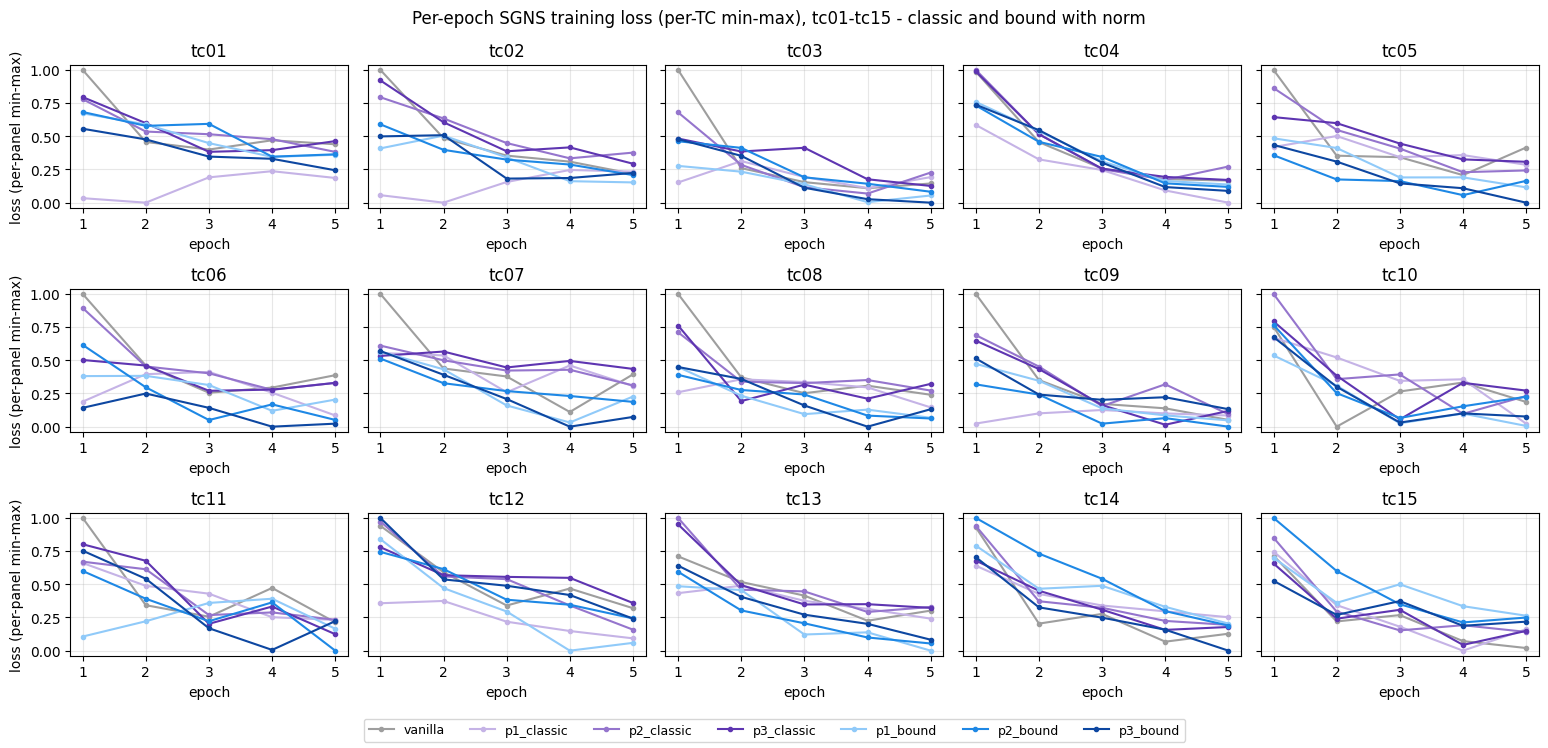

In [2]:
# norm=8 classic
plot_combined_loss("synthetic_benchmark_ms_norm")

## Accuracy — p1/p2/p3 classic: with norm vs without norm (per TC)

Final-epoch LogReg test accuracy for the classic variants, comparing the normalized (norm$=8$) init
against the no-norm raw-mean init, for every TC. If normalization were doing real work the bars would
diverge; the per-variant mean $|\Delta|$ vs the vanilla run-to-run noise floor tells us whether any gap
is signal or noise.

In [3]:
"""Accuracy table: p1/p2/p3 classic, with norm vs without norm, per TC (reuses ROOT/np/json/CURVE_TCS)."""
import pandas as pd

ACC_NORM = ROOT / "output" / "synthetic_benchmark_ms_norm"
ACC_NONORM = ROOT / "output" / "synthetic_benchmark_ms_nonorm"
ACC_VARS = ["p1_classic", "p2_classic", "p3_classic"]

def _facc(base, tc, v):
    f = base / tc / v / "metrics.json"
    return json.loads(f.read_text())["final_acc"] if f.is_file() else np.nan

_rows = []
for tc in CURVE_TCS:
    rec = {"tc": tc}
    for v in ACC_VARS:
        p = v.split("_")[0]
        n, m = _facc(ACC_NORM, tc, v), _facc(ACC_NONORM, tc, v)
        rec[(p, "norm")] = n
        rec[(p, "no-norm")] = m
        rec[(p, "Δ")] = m - n
    _rows.append(rec)
acc_df = pd.DataFrame(_rows).set_index("tc")
acc_df.columns = pd.MultiIndex.from_tuples(acc_df.columns)

print("mean |Δ| in final accuracy (no-norm − norm):")
for p in ["p1", "p2", "p3"]:
    d = acc_df[(p, "Δ")].abs()
    print(f"  {p}_classic: mean={d.mean():.4f}  max={d.max():.4f}")
_alld = pd.concat([acc_df[(p, "Δ")].abs() for p in ["p1", "p2", "p3"]])
print(f"  all classic: mean={_alld.mean():.4f}  max={_alld.max():.4f}  (vanilla noise floor ≈ 0.014)")
acc_df.round(3)

mean |Δ| in final accuracy (no-norm − norm):
  p1_classic: mean=0.0216  max=0.0700
  p2_classic: mean=0.0188  max=0.0650
  p3_classic: mean=0.0193  max=0.0700
  all classic: mean=0.0199  max=0.0700  (vanilla noise floor ≈ 0.014)


p1                    p2                    p3               
       norm no-norm      Δ   norm no-norm      Δ   norm no-norm      Δ
tc                                                                    
tc01  0.942   0.938 -0.005  0.940   0.958  0.018  0.955   0.940 -0.015
tc02  0.865   0.872  0.008  0.845   0.868  0.023  0.842   0.848  0.005
tc03  0.922   0.940  0.017  0.925   0.942  0.017  0.918   0.952  0.035
tc04  0.998   1.000  0.002  1.000   1.000  0.000  1.000   1.000  0.000
tc05  0.928   0.858 -0.070  0.915   0.850 -0.065  0.955   0.942 -0.012
tc06  0.988   0.982 -0.005  0.988   0.980 -0.008  0.985   0.988  0.003
tc07  0.548   0.555  0.008  0.555   0.598  0.042  0.570   0.592  0.023
tc08  0.560   0.588  0.027  0.610   0.590 -0.020  0.578   0.605  0.027
tc09  0.608   0.650  0.042  0.642   0.642  0.000  0.630   0.630  0.000
tc10  0.650   0.685  0.035  0.682   0.665 -0.017  0.700   0.700  0.000
tc11  0.620   0.615 -0.005  0.632   0.632  0.000  0.680   0.610 -0.070
tc12  0.655   0.658  0.002  0.725   0.680 -0.045  0.672   0.655 -0.017
tc13  0.535   0.512 -0.023  0.515   0.508 -0.007  0.583   0.526 -0.057
tc14  0.986   1.000  0.014  0.982   0.998  0.016  0.996   1.000  0.004
tc15  0.585   0.525 -0.060  0.556   0.552 -0.004  0.548   0.527 -0.021

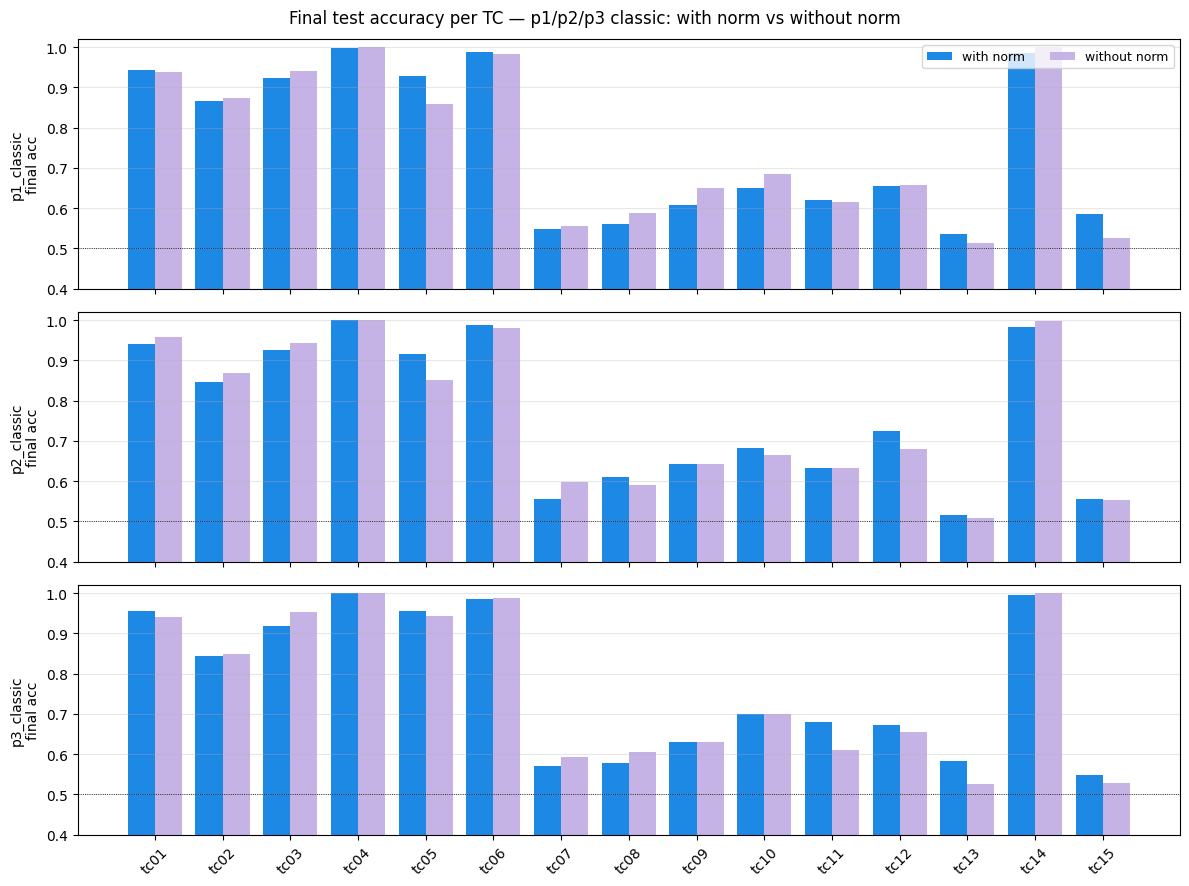

In [4]:
"""Grouped bars: per-TC final accuracy for p1/p2/p3 classic — with norm vs without norm."""
x = np.arange(len(CURVE_TCS))
w = 0.4
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, p in zip(axes, ["p1", "p2", "p3"]):
    ax.bar(x - w / 2, [acc_df.loc[tc, (p, "norm")] for tc in CURVE_TCS], w, label="with norm", color="#1e88e5")
    ax.bar(x + w / 2, [acc_df.loc[tc, (p, "no-norm")] for tc in CURVE_TCS], w, label="without norm", color="#c5b3e6")
    ax.axhline(0.5, color="k", lw=0.6, ls=":")   # binary-task chance
    ax.set_ylabel(f"{p}_classic\nfinal acc")
    ax.set_ylim(0.4, 1.02)
    ax.grid(alpha=0.3, axis="y")
axes[0].legend(ncol=2, loc="upper right", fontsize=9)
axes[-1].set_xticks(x, CURVE_TCS, rotation=45)
fig.suptitle("Final test accuracy per TC — p1/p2/p3 classic: with norm vs without norm")
fig.tight_layout()
_asset = ROOT / "latex" / "assets" / "compare"
_asset.mkdir(parents=True, exist_ok=True)
fig.savefig(_asset / "acc_classic_norm_vs_nonorm_tc01_tc15.png", dpi=150)
plt.show()